Optional: convert once and be done

If you want to avoid any future friction:

df = pd.read_csv("cleaning_keystone_dataset/cps_00001.csv.gz")
df.to_csv("cleaning_keystone_dataset/cps_00001_clean.csv", index=False)

Then you can use the clean CSV going forward.

In [22]:
import pandas as pd
import numpy as np
df = pd.read_csv("cleaning_keystone_dataset/cps_00001.csv.gz")


In [ ]:
import pandas as pd
import numpy as np


# Create subset

ubi_subset = df[[
    'EDUC',
    'SCHLCOLL',
    'INCWAGE',
    'AGE',
    'SEX',
    'RACE',
    'OCC'
]].copy()


# Cleans income data

ubi_subset['INCWAGE'] = ubi_subset['INCWAGE'].replace(99999999, np.nan)

ubi_subset = ubi_subset.dropna(subset=['INCWAGE'])

ubi_subset = ubi_subset[ubi_subset['INCWAGE'] > 0]


# mapping occupation codes to labels

ubi_subset['OCC'] = ubi_subset['OCC'].astype(str).str.zfill(4)


# Mapping occupation labels

ubi_subset['OCC_LABEL'] = ubi_subset['OCC'].map(occ_dict)


# Sex mapping

sex_map = {
    1: 'Male',
    2: 'Female'
}

ubi_subset['SEX_LABEL'] = ubi_subset['SEX'].map(sex_map)


# Race mapping

race_map = {
    100: 'White',
    200: 'Black',
    300: 'American Indian/Aleut/Eskimo',
    651: 'Asian',
    700: 'Other'
}

ubi_subset['RACE_LABEL'] = ubi_subset['RACE'].map(race_map)



# Final readable dataset

comparison_df = ubi_subset[[
    'INCWAGE',
    'AGE',
    'SEX_LABEL',
    'RACE_LABEL',
    'OCC_LABEL'
]]


# Preview cleaned dataset

comparison_df.head()


,INCWAGE,AGE,SEX_LABEL,RACE_LABEL,OCC_LABEL
4,40000.0,52,Male,White,Customer service representatives
10,61729.0,63,Male,White,Logging workers
14,43000.0,57,Male,White,Janitors and building cleaners
15,25000.0,57,Female,White,NaN
16,20000.0,23,Male,White,"Laborers and freight, stock, and material move..."


Useful Compare/Contrast Analyses

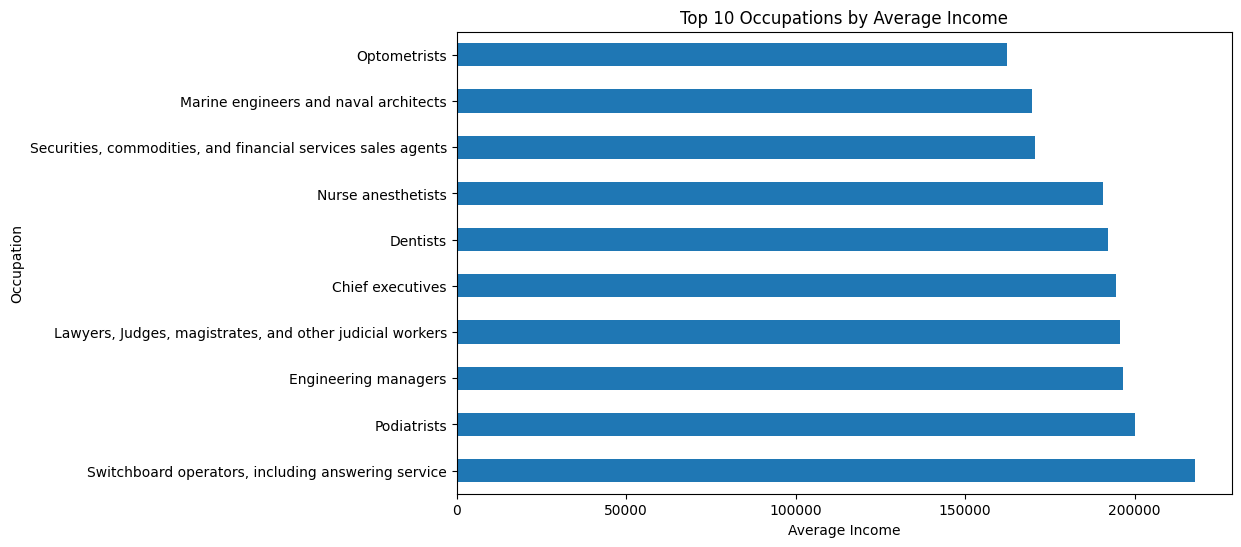

In [29]:
#Average income by occupation

comparison_df.groupby('OCC_LABEL')['INCWAGE'].mean().sort_values(ascending=False)

#Horizontal bar chart

import matplotlib.pyplot as plt

avg_occ_income = (
    comparison_df
    .groupby('OCC_LABEL')['INCWAGE']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

avg_occ_income.plot(kind='barh')

plt.title('Top 10 Occupations by Average Income')
plt.xlabel('Average Income')
plt.ylabel('Occupation')

plt.show()

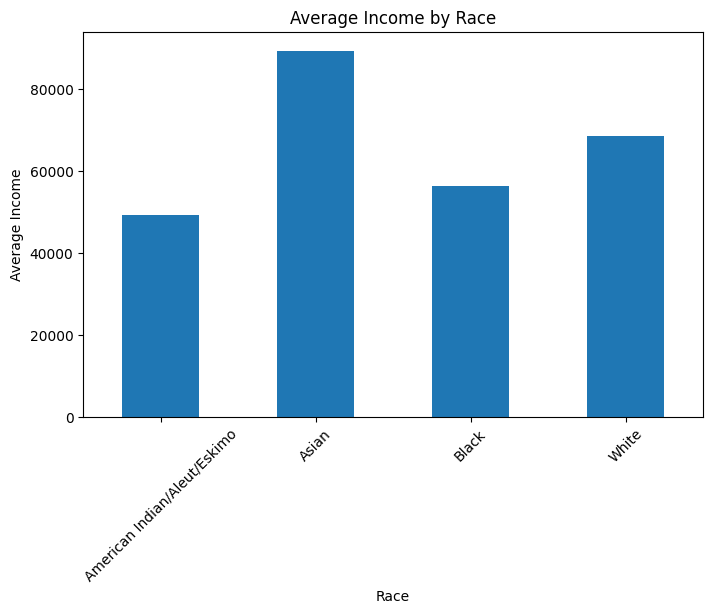

In [30]:
#Average income by race

comparison_df.groupby('RACE_LABEL')['INCWAGE'].mean()

avg_race_income = (
    comparison_df
    .groupby('RACE_LABEL')['INCWAGE']
    .mean()
)

plt.figure(figsize=(8,5))

avg_race_income.plot(kind='bar')

plt.title('Average Income by Race')
plt.xlabel('Race')
plt.ylabel('Average Income')

plt.xticks(rotation=45)

plt.show()


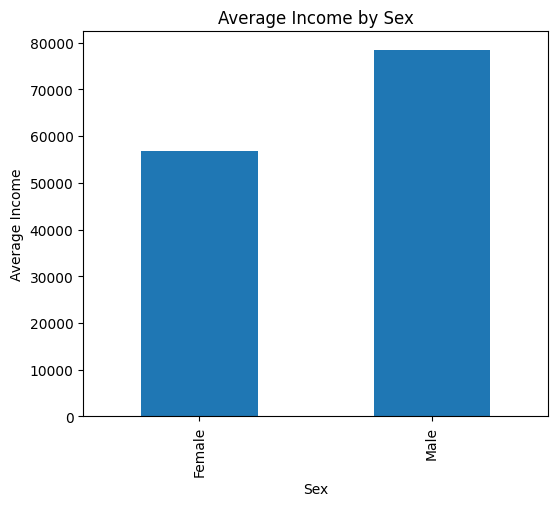

In [31]:
#Average income by sex

comparison_df.groupby('SEX_LABEL')['INCWAGE'].mean()

avg_sex_income = (
    comparison_df
    .groupby('SEX_LABEL')['INCWAGE']
    .mean()
)

plt.figure(figsize=(6,5))

avg_sex_income.plot(kind='bar')

plt.title('Average Income by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Income')

plt.show()

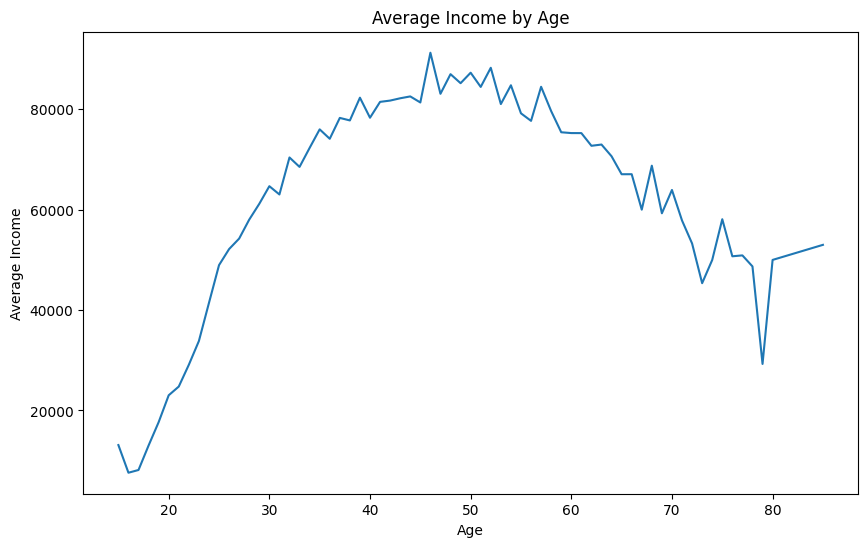

In [34]:
#Compare age distributions

comparison_df.groupby('OCC_LABEL')['AGE'].mean()

age_income = (
    comparison_df
    .groupby('AGE')['INCWAGE']
    .mean()
)

plt.figure(figsize=(10,6))

plt.plot(age_income.index, age_income.values)

plt.title('Average Income by Age')
plt.xlabel('Age')
plt.ylabel('Average Income')

plt.show()


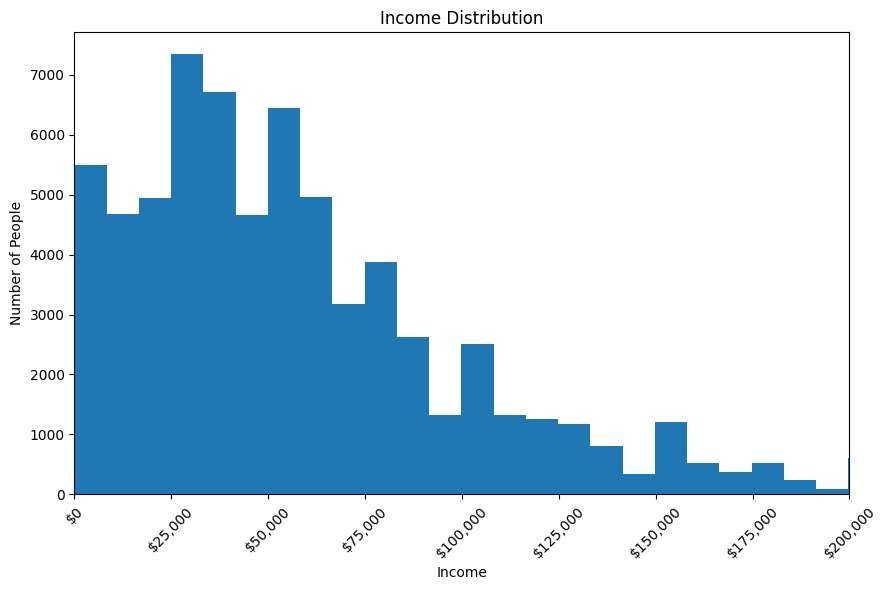

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


filtered_income = comparison_df[
    comparison_df['INCWAGE'] < 250000
]


plt.figure(figsize=(10,6))

plt.hist(filtered_income['INCWAGE'], bins=30)


plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of People')


plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)

# Optional: limit x-axis
plt.xlim(0, 200000)


plt.show()

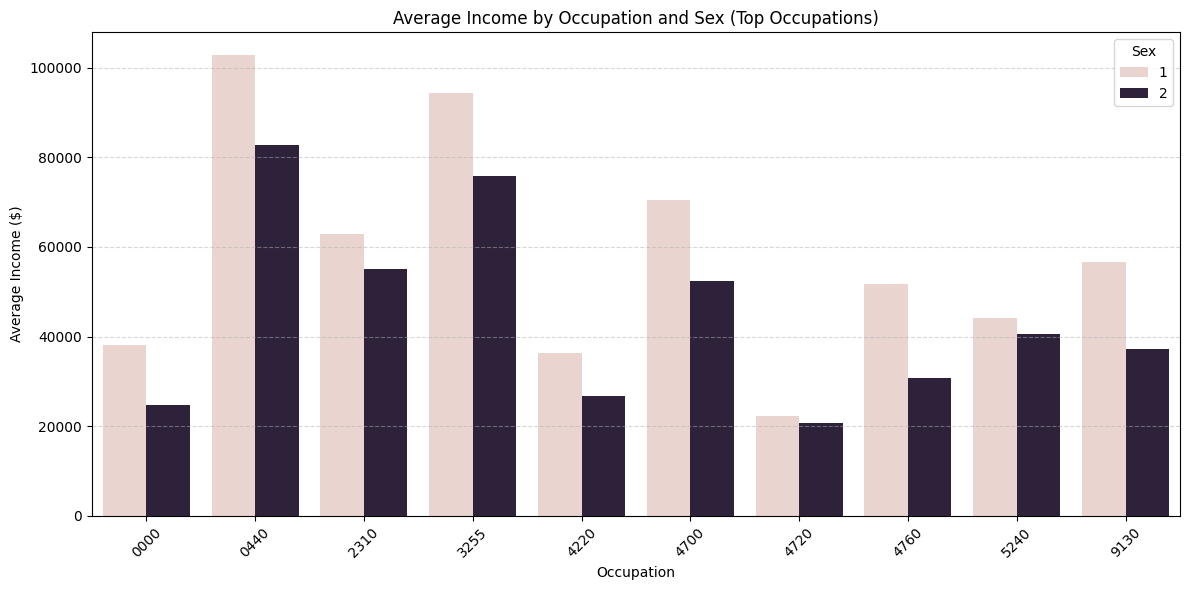

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_clean = df.copy()

# Remove missing/zero income
df_clean = df_clean[df_clean["INCWAGE"] > 0]

# Remove extreme outliers (top-coded / data errors)
df_clean = df_clean[df_clean["INCWAGE"] < 300000]


top_occ = df_clean["OCC"].value_counts().head(10).index
df_top = df_clean[df_clean["OCC"].isin(top_occ)]



occ_map = {
    # Example placeholders (replace if you have real CPS mapping)
    0: "Unknown",
    3100: "Managers",
    2170: "Teachers",
    3090: "Engineers"
}

df_top["OCC"] = df_top["OCC"].map(occ_map).fillna(df_top["OCC"])



avg_income_occ_sex = (
    df_top.groupby(["OCC", "SEX"])["INCWAGE"]
    .mean()
    .reset_index()
)

avg_income_occ_sex.columns = ["Occupation", "Sex", "Average Income"]


plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_income_occ_sex,
    x="Occupation",
    y="Average Income",
    hue="Sex"
)

plt.title("Average Income by Occupation and Sex (Top Occupations)")
plt.xlabel("Occupation")
plt.ylabel("Average Income ($)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Create subset

ubi_subset = df[[
    'EDUC',
    'SCHLCOLL',
    'INCWAGE',
    'AGE',
    'SEX',
    'RACE',
    'OCC'
]].copy()


# Cleans income data

ubi_subset['INCWAGE'] = ubi_subset['INCWAGE'].replace(99999999, np.nan)

ubi_subset = ubi_subset.dropna(subset=['INCWAGE'])

ubi_subset = ubi_subset[ubi_subset['INCWAGE'] > 0]


# mapping occupation codes to labels

ubi_subset['OCC'] = ubi_subset['OCC'].astype(str).str.zfill(4)


# Mapping occupation labels

ubi_subset['OCC_LABEL'] = ubi_subset['OCC'].map(occ_dict)


# Sex mapping

sex_map = {
    1: 'Male',
    2: 'Female'
}

ubi_subset['SEX_LABEL'] = ubi_subset['SEX'].map(sex_map)


# Race mapping

race_map = {
    100: 'White',
    200: 'Black',
    300: 'American Indian/Aleut/Eskimo',
    651: 'Asian',
    700: 'Other'
}

ubi_subset['RACE_LABEL'] = ubi_subset['RACE'].map(race_map)



# Final readable dataset

comparison_df = ubi_subset[[
    'INCWAGE',
    'AGE',
    'SEX_LABEL',
    'RACE_LABEL',
    'OCC_LABEL'
]]


# Preview cleaned dataset

comparison_df.head()







,INCWAGE,AGE,SEX_LABEL,RACE_LABEL,OCC_LABEL
4,40000.0,52,Male,White,Customer service representatives
10,61729.0,63,Male,White,Logging workers
14,43000.0,57,Male,White,Janitors and building cleaners
15,25000.0,57,Female,White,NaN
16,20000.0,23,Male,White,"Laborers and freight, stock, and material move..."


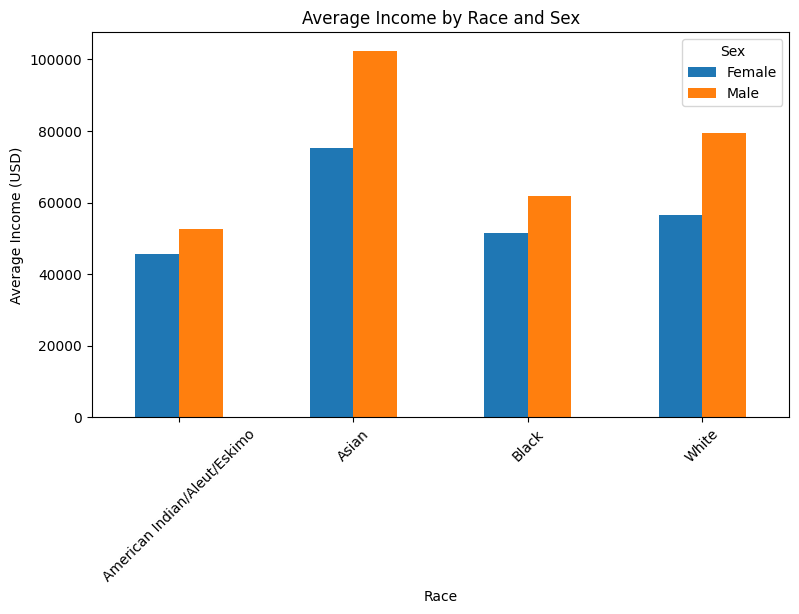

In [59]:
import matplotlib.pyplot as plt

avg_income = (
    comparison_df
    .dropna(subset=['RACE_LABEL', 'SEX_LABEL', 'INCWAGE'])
    .groupby(['RACE_LABEL', 'SEX_LABEL'])['INCWAGE']
    .mean()
    .unstack()
)

avg_income.plot(kind='bar', figsize=(9,5))

plt.title('Average Income by Race and Sex')
plt.xlabel('Race')
plt.ylabel('Average Income (USD)')
plt.xticks(rotation=45)
plt.legend(title='Sex')

plt.show()

In [60]:
print(comparison_df.columns)

Index(['INCWAGE', 'AGE', 'SEX_LABEL', 'RACE_LABEL', 'OCC_LABEL'], dtype='str')


###Produce Polished Visuals That Communicate Your Story:  
Create a small set of polished, high-quality visuals for your Keystone Project. Each visual should include a short markdown explanation addressing:

What question or idea this chart helps answer
Why this chart type is appropriate
What design choices you made (color, labels, order, scale)
How you ensured accuracy and avoided misleading design
This is where your project begins to shift from exploration to communication.###

Universal Basic Income (UBI)- What it means, from one person to next, may vary a little. Here the UBI is described as Income given freely based on happiness; just as what it means may vary, the criteria is a bit shrouded. I on the other hand, sought out indicators, that could predetermine ones happiness.  In the United States, it is believed that certain markers indicate 'having arrived' or 'made it' in society, here I have listed education-highschool and college, income, age, sex, race, and occupation. The fields I have chosen as indicators, also, have a history of disparages. 

a flow chart Income - Expendiutures = Discretionary/non-essential Income...If you do the math...

Next then given the disparages what are societal factors, or a factor that can bring down happiness, even after having arrived. Here I would like to take a look at deviant behaviors that could cause a break a rift, a decline in society, causing unhappiness. One major factor associated with unhappiness outside of the societal norms, could be crime. Crime and its effects and affects on society. Could the the UBI be used to acknowledge the loss = unhappiness to society caused by crime, and head it off?  Could the UBI break the cycles that plague us, generation after generation? Can the UBI provide hope, in a hopless situation, or an even more hopeless, world? 

The effects and affects of crime and the community. A chart showing how crime can effect and affect the overall median income in a society, and the possible results if left unchecked, anywhere from upheaval to dissolution of the state.

Again, in conclusion I would like to state that given the disparages of society, that could be argued as the trickle down economics of a domminant or dominant classes and 'scarcity of goods' within society.  Society, cultures, develop natural fissure, due to wear and tear, but the one thing that gets us all, eventually, is time. The only unnatural occuring theme here is crime; and that usually happens due to a lack in vision, I woould argue. 